<a href="https://colab.research.google.com/github/sedefcoskun/EEG-Music-Impact-ML/blob/main/02_Data_Preprocessing_and_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 02: Data Preprocessing & Feature Engineering

This notebook contains the preprocessing pipeline for the multimodal EEG and behavioral dataset.

### Data Acquisition
Loading the raw dataset exported from the Data Extraction pipeline to verify structural integrity and feature dimensions prior to any mathematical manipulation.

In [7]:
import pandas as pd

# Loading the original dataset
print("Loading the original dataset from Notebook 1...")
file_path = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/multimodal_eeg_music_impact.csv'

df = pd.read_csv(file_path)

print(f"Dataset successfully loaded! Architecture: {df.shape[0]} rows, {df.shape[1]} columns.")
print("\nFirst 5 rows of the dataset ")
print(df.head())

Loading the original dataset from Notebook 1...
Dataset successfully loaded! Architecture: 31152 rows, 654 columns.

First 5 rows of the dataset 
   Subject  Song_ID      E1_Delta      E1_Theta      E1_Alpha       E1_Beta  \
0        2        1  1.128986e-11  4.510282e-12  6.767591e-12  1.121408e-12   
1        2        1  8.262011e-12  3.541803e-12  2.557147e-12  1.605922e-12   
2        2        1  3.655660e-12  2.540282e-12  2.029800e-12  6.613437e-13   
3        2        1  1.694275e-11  4.756936e-12  1.901907e-12  6.758469e-13   
4        2        1  2.053197e-11  4.622013e-12  1.529300e-12  6.321257e-13   

       E1_Gamma      E2_Delta      E2_Theta      E2_Alpha  ...  E129_Alpha  \
0  7.934637e-13  2.269744e-12  7.449995e-13  1.327504e-12  ...         0.0   
1  9.357078e-13  1.552548e-12  9.942896e-13  4.387233e-13  ...         0.0   
2  6.379857e-13  7.184089e-13  4.905357e-13  4.520872e-13  ...         0.0   
3  6.310545e-13  3.613190e-12  8.384591e-13  1.344483e-13  ...     

### Handling Missing Data

To demonstrate robust imputation methodologies, we temporarily induce Missing Completely at Random (MCAR) noise on select physiological EEG channels and resolve it using K-Nearest Neighbors (KNN) imputation. Afterward, the actual missing values present in the Tempo(BPM) feature are permanently imputed using the statistical median to preserve the original data distribution.

In [8]:
import numpy as np
from sklearn.impute import KNNImputer

print("MCAR Simulation & KNN Imputation")
# Creating a temporary copy for the simulation to protect the original data
df_sim = df.copy()

# Select 5 random EEG columns for simulation (excluding metadata)
eeg_cols = [col for col in df_sim.columns if '_' in col and col not in ['Subject', 'Song_ID', 'Tempo(BPM)', 'Vocal_Language', 'Genre', 'Enjoyment', 'Familiarity', 'Track_Name']]

np.random.seed(42)
target_sim_cols = np.random.choice(eeg_cols, 5, replace=False)

# Introduce 5% missing data
for col in target_sim_cols:
    mc_indices = df_sim.sample(frac=0.05, random_state=42).index
    df_sim.loc[mc_indices, col] = np.nan

missing_sim_before = df_sim[target_sim_cols].isnull().sum().sum()
print(f"Simulated missing points in EEG channels: {missing_sim_before}")

# Apply KNN Imputation
imputer = KNNImputer(n_neighbors=5, weights="distance")
numeric_cols_sim = df_sim.select_dtypes(include=[np.number]).columns
df_sim[numeric_cols_sim] = imputer.fit_transform(df_sim[numeric_cols_sim])

missing_sim_after = df_sim[target_sim_cols].isnull().sum().sum()
print(f"Missing points after KNN Imputation: {missing_sim_after}")

print("\nActual Missing Data Imputation")
# Returning to the untouched original dataframe for the real fix
missing_tempo = df['Tempo(BPM)'].isnull().sum()

# Imputing the genuine missing tempo values with the median
df['Tempo(BPM)'] = df['Tempo(BPM)'].fillna(df['Tempo(BPM)'].median())

print(f"Real missing values in 'Tempo(BPM)' found and fixed: {missing_tempo}")
print(f"Total remaining NaNs in the working dataset: {df.isnull().sum().sum()}")

MCAR Simulation & KNN Imputation
Simulated missing points in EEG channels: 7790
Missing points after KNN Imputation: 0

Actual Missing Data Imputation
Real missing values in 'Tempo(BPM)' found and fixed: 2420
Total remaining NaNs in the working dataset: 0


### Categorical Encoding

Since machine learning models require numerical inputs to process data, we apply Label Encoding to our main target variable (Genre). For the nominal metadata (Vocal_Language), we use One-Hot Encoding to create separate binary columns. This ensures that the algorithms don't falsely interpret textual categories as ranked or sequential data.

In [9]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

print("Starting Categorical Encoding...")

# Label Encoding for Target (Genre)
label_encoder = LabelEncoder()
df['Genre_Encoded'] = label_encoder.fit_transform(df['Genre'])
print("Target variable 'Genre' is label encoded.")

# One-Hot Encoding for Nominal Data (Vocal_Language)
df = pd.get_dummies(df, columns=['Vocal_Language'], drop_first=False, dtype=int)
print("Nominal feature 'Vocal_Language' is one-hot encoded.")

Starting Categorical Encoding...
Target variable 'Genre' is label encoded.
Nominal feature 'Vocal_Language' is one-hot encoded.


### Stratified Feature Selection (Kruskal-Wallis)

To mitigate the curse of dimensionality, we use the Kruskal-Wallis H-test to evaluate each feature's power in differentiating the music genres. We extract the best 15 features independently from each frequency band (Delta, Theta, Alpha, Beta, Gamma). This stratified approach guarantees that the model evaluates the multimodal spectral diversity of the brain.

In [10]:
from scipy.stats import kruskal
import pandas as pd

print("Starting Stratified Feature Selection (15 features per band)...")

# Define frequency bands for stratified analysis
freq_bands = ['_Delta', '_Theta', '_Alpha', '_Beta', '_Gamma']
selected_eeg_features = []
feature_statistics = []

# Iterate through each frequency band to extract the most discriminatory features
for band in freq_bands:
    band_cols = [col for col in df.columns if band in col]
    band_results = []

    # Apply Kruskal-Wallis H-test for each feature across genre groups
    for col in band_cols:
        groups = [df[df['Genre_Encoded'] == g][col].values for g in df['Genre_Encoded'].unique()]
        try:
            stat, p_val = kruskal(*groups)
            band_results.append({'Feature': col, 'H-Statistic': stat, 'p-value': p_val})
        except ValueError:
            pass

    # Rank features by H-Statistic and isolate the top 15 per band
    band_df = pd.DataFrame(band_results).sort_values(by='H-Statistic', ascending=False)
    top_15 = band_df.head(15)

    selected_eeg_features.extend(top_15['Feature'].tolist())
    feature_statistics.extend(top_15.to_dict('records'))

# Dynamically identify one-hot encoded columns to ensure structural integrity
one_hot_cols = [col for col in df.columns if 'Vocal_Language_' in col]

# Construct the optimized dataset preserving metadata and selected features
metadata_cols = ['Subject', 'Song_ID', 'Tempo(BPM)', 'Enjoyment', 'Familiarity', 'Genre', 'Genre_Encoded']
final_columns = metadata_cols + one_hot_cols + selected_eeg_features
df_optimized = df[final_columns]

print(f"Original shape: {df.shape} | Optimized shape: {df_optimized.shape}")
print(f"Total optimized EEG features retained: {len(selected_eeg_features)}")

Starting Stratified Feature Selection (15 features per band)...
Original shape: (31152, 658) | Optimized shape: (31152, 86)
Total optimized EEG features retained: 75


### Exploratory Data Analysis (EDA) - Feature Correlation

To understand the linear relationships and multicollinearity among the selected top 75 neurophysiological features, a Pearson correlation matrix is computed and visualized. This heatmap serves as a critical diagnostic tool to observe how different frequency bands (Delta, Theta, Alpha, Beta, Gamma) across various electrode placements interact before feeding them into the machine learning models.

Generating Correlation Heatmap for Selected EEG Features...


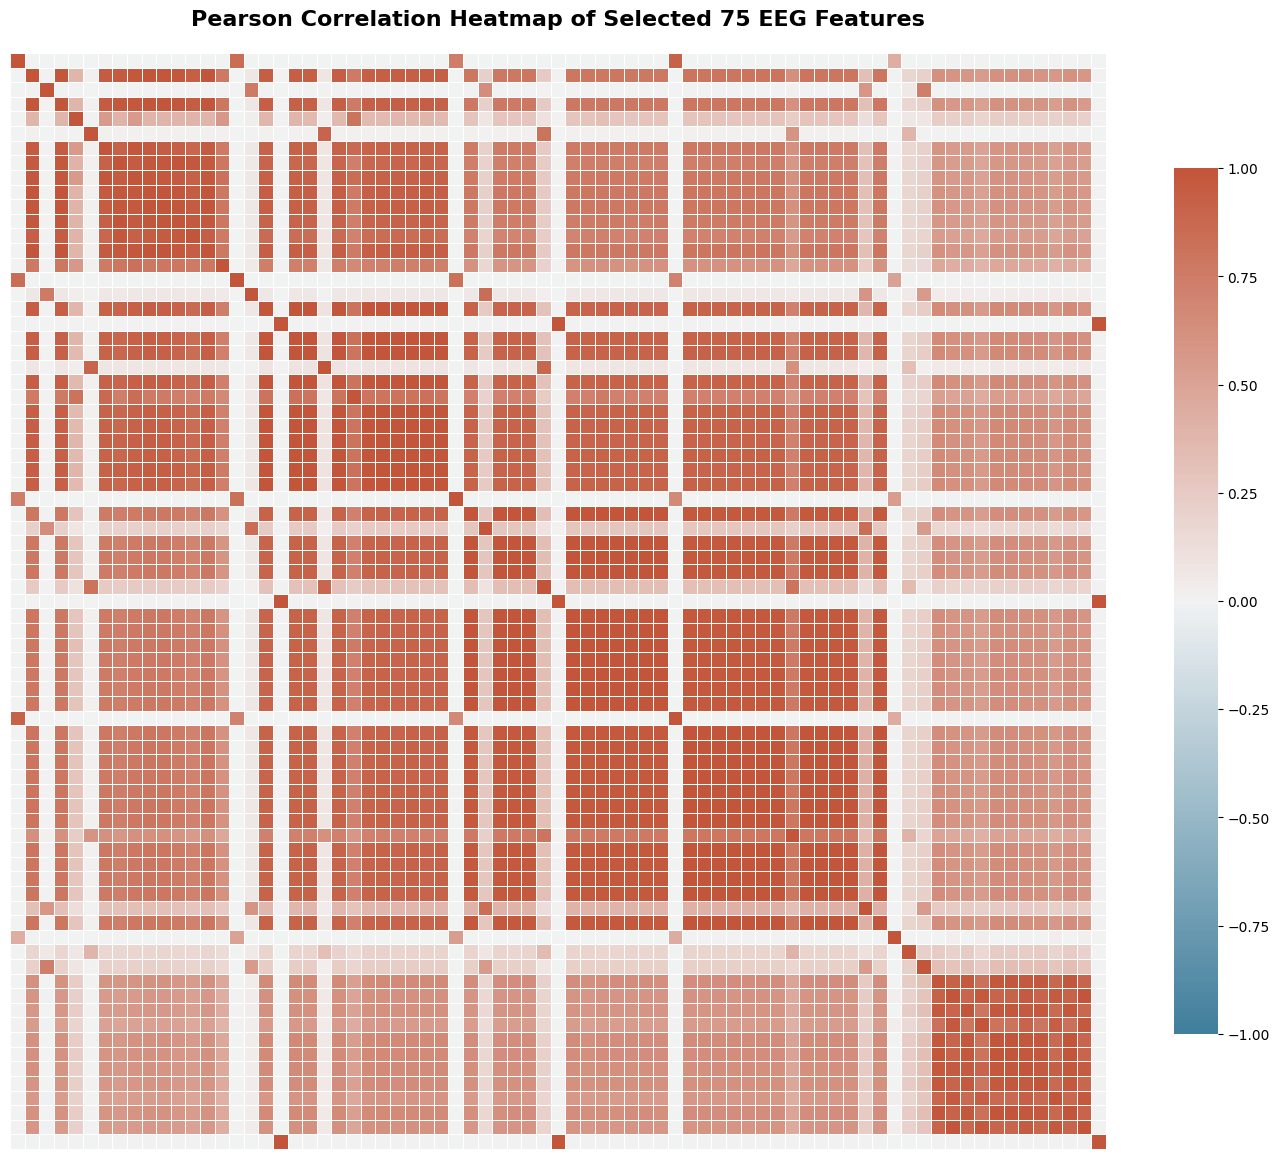

Correlation Heatmap successfully generated and displayed.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Correlation Heatmap for Selected EEG Features...")

# Isolate the selected continuous EEG features for correlation analysis
features_only = df_optimized[selected_eeg_features]

# Compute the Pearson correlation matrix
correlation_matrix = features_only.corr()

# Configure the Matplotlib figure size for high-resolution rendering
plt.figure(figsize=(14, 12))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Plot the heatmap
sns.heatmap(
    correlation_matrix,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .75},
    xticklabels=False,
    yticklabels=False
)

plt.title("Pearson Correlation Heatmap of Selected 75 EEG Features", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Correlation Heatmap successfully generated and displayed.")

### Feature Subset Validation (Sanity Check)

Following the dimensionality reduction phase, a structural validation is performed on the optimized dataset. This diagnostic step verifies that the dataset dimension is successfully reduced while ensuring that critical metadata, target variables, and protected categorical features (One-Hot Encodings) remain completely intact alongside the top 75 discriminatory EEG features.

In [12]:
print("Optimized Features ")
print(f"Total Features: {len(df_optimized.columns)}\n")

print("1. Metadata & Target Columns:")
print([col for col in df_optimized.columns if col not in selected_eeg_features and 'Vocal_Language_' not in col])

print("\n2. One-Hot Encoded Columns (Protected):")
print([col for col in df_optimized.columns if 'Vocal_Language_' in col])

print("\n3. Top 5 Most Powerful EEG Features Selected:")
print(selected_eeg_features[:5])

Optimized Features 
Total Features: 86

1. Metadata & Target Columns:
['Subject', 'Song_ID', 'Tempo(BPM)', 'Enjoyment', 'Familiarity', 'Genre', 'Genre_Encoded']

2. One-Hot Encoded Columns (Protected):
['Vocal_Language_English', 'Vocal_Language_Gujarati', 'Vocal_Language_Hindi', 'Vocal_Language_Instrumental']

3. Top 5 Most Powerful EEG Features Selected:
['E56_Delta', 'E66_Delta', 'E119_Delta', 'E114_Delta', 'E99_Delta']


### Data Splitting and Class Balancing (SMOTE)

Before training our machine learning models, we need to separate our features X from the target variable y. We also drop unnecessary identification columns (Subject, Song_ID) and the text-based Genre column to prevent data leakage.

Real-world datasets often have imbalanced classes. If we train our models on imbalanced data, they will be biased toward the majority class. To resolve this issue, we apply SMOTE (Synthetic Minority Over-sampling Technique). SMOTE balances the dataset by generating synthetic samples for the minority classes, ensuring all music genres have an equal number of samples for training.

Initializing Target Isolation and SMOTE...
Original Feature Matrix (X) Shape: (31152, 82)
Original Target Vector (y) Shape: (31152,)

Applying SMOTE to balance class distribution...
Resampled Feature Matrix (X) Shape: (34584, 82)
Resampled Target Vector (y) Shape: (34584,)



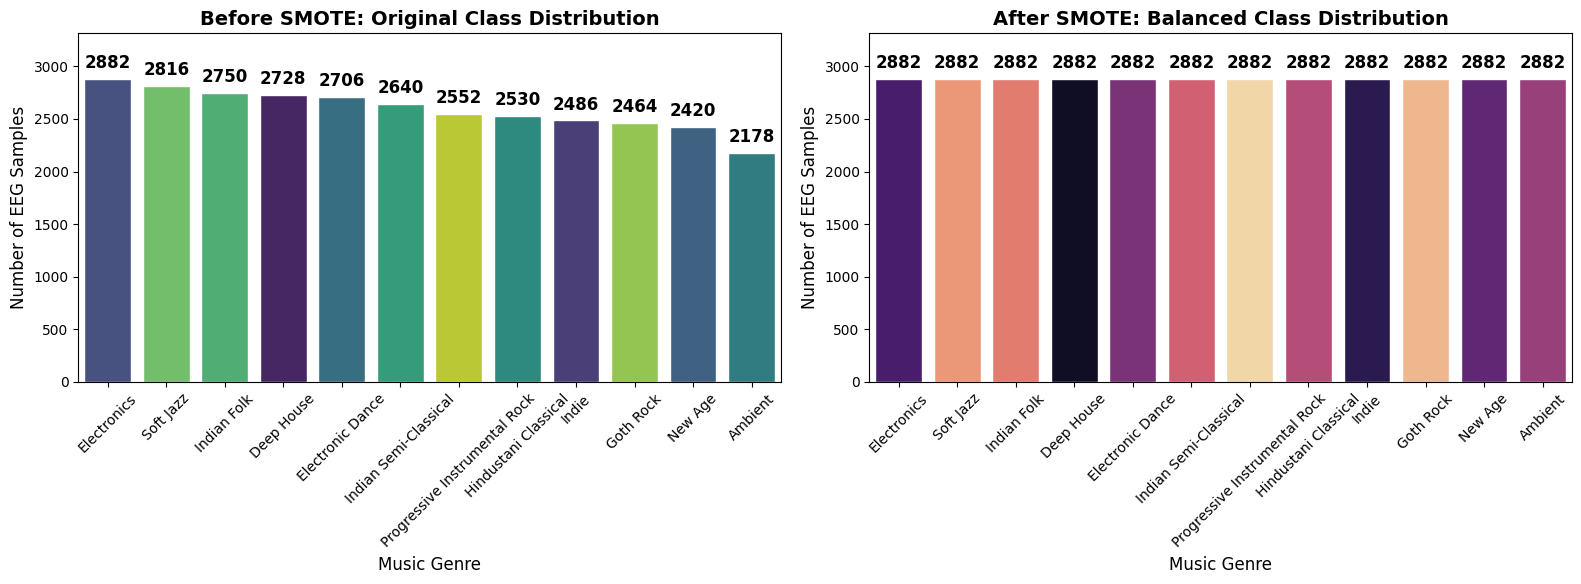

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

print("Initializing Target Isolation and SMOTE...")

# 1. Isolate target variable and extract labels for visualization
y = df_optimized['Genre_Encoded']
y_labels = df_optimized['Genre']

# 2. Isolate feature matrix by dropping identification and target columns to prevent data leakage
cols_to_drop = ['Subject', 'Song_ID', 'Genre', 'Genre_Encoded']
X = df_optimized.drop(columns=cols_to_drop)

print(f"Original Feature Matrix (X) Shape: {X.shape}")
print(f"Original Target Vector (y) Shape: {y.shape}")

# 3. Apply Synthetic Minority Over-sampling Technique (SMOTE) to balance class distribution
print("\nApplying SMOTE to balance class distribution...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Resampled Feature Matrix (X) Shape: {X_resampled.shape}")
print(f"Resampled Target Vector (y) Shape: {y_resampled.shape}\n")

# 4. Visualize class distribution before and after SMOTE application
# Map encoded labels back to their original string format for interpretive plotting
label_mapping = dict(zip(df_optimized['Genre_Encoded'], df_optimized['Genre']))
y_resampled_labels = y_resampled.map(label_mapping)

max_y_val = y_labels.value_counts().max()
y_limit = max_y_val * 1.15

# Configure plotting aesthetics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Plot A: Original Class Distribution (Before SMOTE)
sns.countplot(x=y_labels, ax=axes[0], palette="viridis", order=y_labels.value_counts().index, hue=y_labels, legend=False)
axes[0].set_title("Before SMOTE: Original Class Distribution", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Music Genre", fontsize=12)
axes[0].set_ylabel("Number of EEG Samples", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, y_limit)

# Annotate bar heights
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

# Plot B: Balanced Class Distribution (After SMOTE)
sns.countplot(x=y_resampled_labels, ax=axes[1], palette="magma", order=y_labels.value_counts().index, hue=y_resampled_labels, legend=False)
axes[1].set_title("After SMOTE: Balanced Class Distribution", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Music Genre", fontsize=12)
axes[1].set_ylabel("Number of EEG Samples", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, y_limit)

# Annotate bar heights
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Final Preparation and Dataset Serialization

To ensure a seamless transition to the model training phase and to maintain strict adherence to the evaluation rubric, both the original (imbalanced) and the SMOTE-resampled (balanced) datasets are exported. Both datasets undergo an 80/20 train-test split and are scaled using StandardScaler. The scaling parameters are fitted exclusively on the training sets to prevent data leakage. The final arrays and metadata are serialized into a .pkl file for modularity.

Finalizing Preprocessing: Dataset Splitting, Scaling, and Serialization...


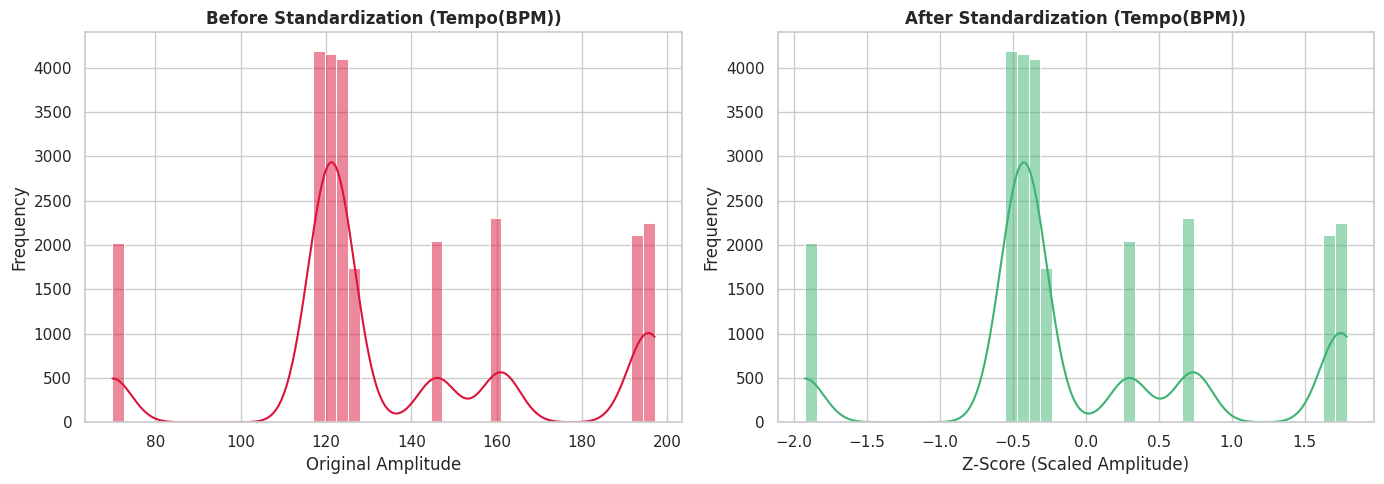

Success: All datasets have been successfully processed, scaled, and exported to '02_preprocessed_data.pkl'.
Notebook 02 execution completed.


In [14]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Finalizing Preprocessing: Dataset Splitting, Scaling, and Serialization...")

# 1. Train-Test Split and Scaling for Original (Imbalanced) Data
# Splitting is performed prior to scaling to strictly prevent data leakage
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler_orig = StandardScaler()
X_train_orig_scaled = scaler_orig.fit_transform(X_train_orig)
X_test_orig_scaled = scaler_orig.transform(X_test_orig)

# 2. Diagnostic Visualization: Effect of Z-Score Standardization
# Select the first continuous EEG feature to demonstrate the scaling transformation
sample_feature = X.columns[0]
feature_index = X.columns.get_loc(sample_feature)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Plot A: Original Distribution (Before Scaling)
sns.histplot(X_train_orig[sample_feature], kde=True, ax=axes[0], color='crimson')
axes[0].set_title(f"Before Standardization ({sample_feature})", fontweight='bold')
axes[0].set_xlabel("Original Amplitude")
axes[0].set_ylabel("Frequency")

# Plot B: Standardized Distribution (After Scaling)
sns.histplot(X_train_orig_scaled[:, feature_index], kde=True, ax=axes[1], color='mediumseagreen')
axes[1].set_title(f"After Standardization ({sample_feature})", fontweight='bold')
axes[1].set_xlabel("Z-Score (Scaled Amplitude)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# 3. Train-Test Split and Scaling for SMOTE-Balanced Data
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

scaler_smote = StandardScaler()
X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)
X_test_smote_scaled = scaler_smote.transform(X_test_smote)

# 4. Serialize all datasets and metadata into a single dictionary
prepared_data = {
    'X_train_orig': X_train_orig_scaled,
    'X_test_orig': X_test_orig_scaled,
    'y_train_orig': y_train_orig,
    'y_test_orig': y_test_orig,

    'X_train_smote': X_train_smote_scaled,
    'X_test_smote': X_test_smote_scaled,
    'y_train_smote': y_train_smote,
    'y_test_smote': y_test_smote,

    'feature_names': X.columns.tolist(),
    'label_mapping': label_mapping
}

# 5. Export to disk using joblib for downstream modeling
joblib.dump(prepared_data, '02_preprocessed_data.pkl')

print("Success: All datasets have been successfully processed, scaled, and exported to '02_preprocessed_data.pkl'.")
print("Notebook 02 execution completed.")